In [1]:
import pandas as pd
import numpy as np
from tqdm import tqdm
from sklearn.model_selection import train_test_split
import pickle
import os
import random
from collections import defaultdict

In [2]:
RANDOM_SEED = 42
TEST_SIZE = 0.4
VAL_TEST_RATIO = 0.5
OUTPUT_DIR = '../splits_jews'

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

data = pd.read_csv('CR_Jews_graph_ibd_labels.csv')
data['node_id1'] = data['node_id1'].apply(lambda x: int(x[5:]))
data['node_id2'] = data['node_id2'].apply(lambda x: int(x[5:]))

In [4]:
df = pd.concat([
    data[['node_id1', 'label_id1']].rename(columns={'node_id1': 'node_id', 'label_id1': 'label'}),
    data[['node_id2', 'label_id2']].rename(columns={'node_id2': 'node_id', 'label_id2': 'label'})
], ignore_index=True)
df = df.drop_duplicates(subset=['node_id'])

max_node = max(data['node_id1'].max(), data['node_id2'].max())

known_nodes = []

for _, row in tqdm(df.iterrows(), desc="Processing nodes"):
    known_nodes.append(row['node_id'])

known_nodes = sorted(list(set(known_nodes)))
print(f"Known nodes: {len(known_nodes)}")

Processing nodes: 10992it [00:00, 29840.31it/s]

Known nodes: 10992


In [5]:
train_nodes_orig, temp_nodes = train_test_split(
    known_nodes, test_size=TEST_SIZE, random_state=RANDOM_SEED
)
val_nodes_orig, test_nodes_orig = train_test_split(
    temp_nodes, test_size=VAL_TEST_RATIO, random_state=RANDOM_SEED
)

print(f"Original train nodes: {len(train_nodes_orig)}")
print(f"Original val nodes: {len(val_nodes_orig)}")
print(f"Original test nodes: {len(test_nodes_orig)}")

Original train nodes: 6595
Original val nodes: 2198
Original test nodes: 2199


In [6]:
labels = ['Central-Russia', 'Jews']

In [7]:
back_labels = {val: i for i, val in enumerate(labels)}
back_labels

{'Central-Russia': 0, 'Jews': 1}

In [8]:
nodes = np.zeros((max_node + 1, len(labels)), dtype=np.float32)
edges = defaultdict(list)

for _, row in tqdm(data.iterrows(), total=len(data), desc="Building features and edges"):
    for dct in eval(row['label_id1']):
        for label, percent in dct.items():
            nodes[row['node_id1'], back_labels[label]] = percent / 100.0
    for dct in eval(row['label_id2']):
        for label, percent in dct.items():
            nodes[row['node_id2'], back_labels[label]] = percent / 100.0
    edges[row['node_id1']].append(row['node_id2'])
    edges[row['node_id2']].append(row['node_id1'])

Building features and edges: 100%|██████████| 10707985/10707985 [14:31<00:00, 12284.55it/s]


In [10]:
good_russian = []
for i in range(len(nodes)):
    if nodes[i].sum() > 0.99:
        good_russian.append(nodes[i, 0])

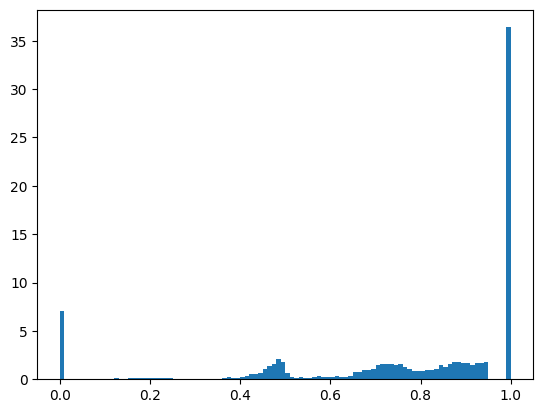

In [12]:
import matplotlib.pyplot as plt
plt.hist(good_russian, bins=100, density=True)
plt.show()

In [8]:
train_nodes = sorted(train_nodes_orig)
val_nodes = sorted(val_nodes_orig)
test_nodes = sorted(test_nodes_orig)

In [9]:
node_labels_masked = nodes.copy()
for n in test_nodes:
    node_labels_masked[n] = np.ones(len(labels)) / len(labels)

In [10]:
# OUTPUT_DIR = '../splits_jews'

In [11]:
os.makedirs(OUTPUT_DIR, exist_ok=True)

np.save(os.path.join(OUTPUT_DIR, 'train_nodes.npy'), np.array(train_nodes, dtype=np.int32))
np.save(os.path.join(OUTPUT_DIR, 'val_nodes.npy'), np.array(val_nodes, dtype=np.int32))
np.save(os.path.join(OUTPUT_DIR, 'test_nodes.npy'), np.array(test_nodes, dtype=np.int32))
np.save(os.path.join(OUTPUT_DIR, 'node_labels.npy'), nodes)
np.save(os.path.join(OUTPUT_DIR, 'node_labels_masked.npy'), node_labels_masked)

print(f"Saved node arrays to {OUTPUT_DIR}")

Saved node arrays to ../splits_jews


In [12]:
pd_pairs = []
for u, vs in tqdm(edges.items(), total=len(edges), desc="Building edge DataFrame"):
    for v in vs:
        pd_pairs.append((u, v))
pd_pairs = pd.DataFrame(pd_pairs, columns=['node_id1', 'node_id2'])
pd_pairs.to_csv(os.path.join(OUTPUT_DIR, 'edges_data.csv'), index=False)
print(f"Saved {len(pd_pairs)} edges")

Building edge DataFrame: 100%|██████████| 10992/10992 [00:04<00:00, 2630.98it/s]


Saved 21415970 edges


In [13]:
with open(os.path.join(OUTPUT_DIR, 'labels.txt'), 'w') as f:
    for label in labels:
        f.write(f"{label}\n")
print(f"Saved {len(labels)} label names")

Saved 2 label names


In [14]:
test_ground_truth = {
    'node_ids': np.array(test_nodes, dtype=np.int32),
    'true_labels': np.array([nodes[n] for n in test_nodes], dtype=np.float32),
    'label_names': labels
}
with open(os.path.join(OUTPUT_DIR, 'test_ground_truth.pkl'), 'wb') as f:
    pickle.dump(test_ground_truth, f)
print("Saved test ground truth file")

Saved test ground truth file
